<a href="https://colab.research.google.com/github/sachin-582/data_sales_analysis-/blob/main/DA_project_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Python Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

#Load Dataset


In [12]:
df = pd.read_csv("/content/big_mart_sales.csv")

df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


#Data Exploration

In [13]:
df.info()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


#Data Cleaning

In [16]:
df['Item_Weight'].fillna(df['Item_Weight'].mean(), inplace=True)

df['Outlet_Size'].fillna('Medium', inplace=True)

/tmp/ipykernel_906/650019705.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Item_Weight'].fillna(df['Item_Weight'].mean(), inplace=True)
/tmp/ipykernel_906/650019705.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=

#Descriptive Statistics

In [17]:
avg_sales = df['Item_Outlet_Sales'].mean()

print("Average Sales:", avg_sales)

Average Sales: 2272.0374886021505


In [18]:
df.groupby('Item_Type')['Item_Outlet_Sales'].mean()

,Item_Outlet_Sales
Item_Type,
Baking Goods,2046.798187
Breads,2389.702474
Breakfast,2203.166638
Canned,2205.210750
Dairy,2337.420556
Frozen Foods,2222.011887
Fruits and Vegetables,2312.703005
Hard Drinks,2233.275299
Health and Hygiene,2138.071282


#Visualization

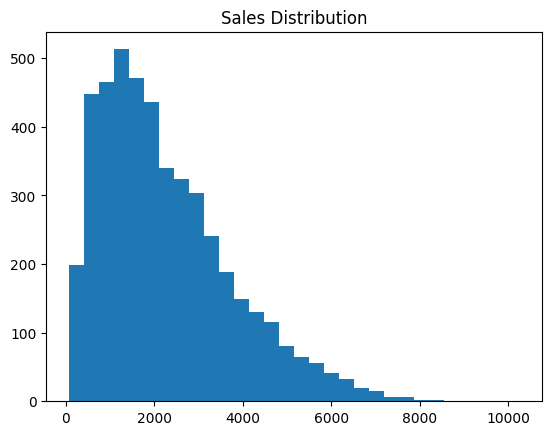

In [19]:
plt.hist(df['Item_Outlet_Sales'], bins=30)
plt.title("Sales Distribution")
plt.show()

#Product Sales

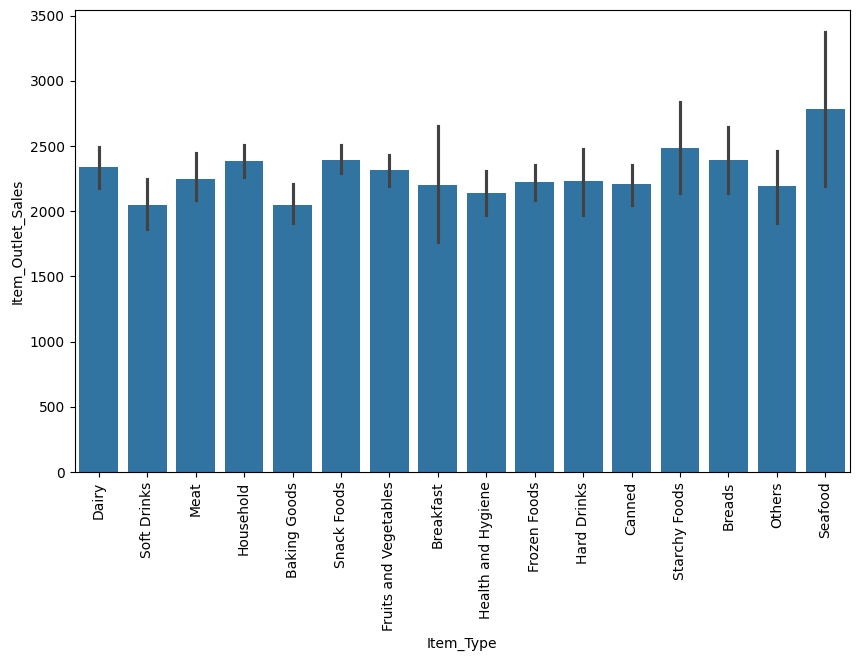

In [20]:
plt.figure(figsize=(10,6))

sns.barplot(x='Item_Type', y='Item_Outlet_Sales', data=df)

plt.xticks(rotation=90)

plt.show()

#Customer / Store Segmentation (K-Means)

In [21]:
X = df[['Item_MRP','Item_Outlet_Sales']]

In [22]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

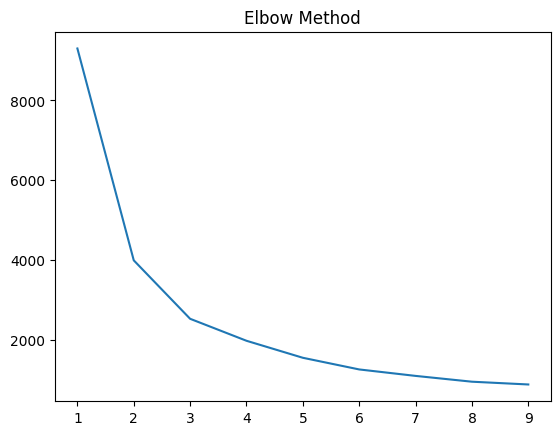

In [23]:
wcss = []

for i in range(1,10):

    kmeans = KMeans(n_clusters=i)

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

plt.plot(range(1,10), wcss)

plt.title("Elbow Method")

plt.show()

#Apply K-Means

In [24]:
kmeans = KMeans(n_clusters=4)

df['Cluster'] = kmeans.fit_predict(X_scaled)

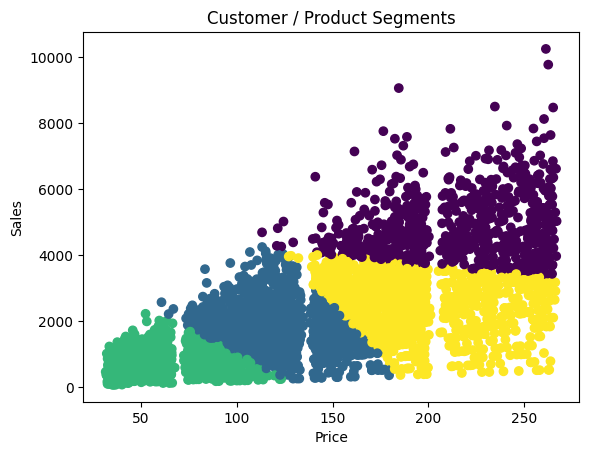

In [25]:
plt.scatter(df['Item_MRP'], df['Item_Outlet_Sales'], c=df['Cluster'])

plt.xlabel("Price")

plt.ylabel("Sales")

plt.title("Customer / Product Segments")

plt.show()